# **1 — EDA : Exploration et Analyse Préliminaire du Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re

# Pour afficher correctement l’arabe
plt.rcParams['font.family'] = 'Arial'

# ============================
# 2. Charger le dataset
# ============================

df = pd.read_excel("/content/final_result1.xlsx")   # adapte le chemin ici


# **Aperçu des données**

In [ ]:
df.head()

,comments,target
0,لا للانتخابات مع العصابات يا البلاد صحافة العار,0
1,قيس السعيد ذكرني بالراحل محمد بوضياف رحمه الله. بالتوفيق لشعب التونسي في اختيارهم,1
2,في رئيي نبيل القروي مخادع لن يصلح أبدا جزائري محب لتونس الشقيقة,1
3,قيس سعيد يبدو اصدق,1
4,اتمنى الا يفوز من تدعمه اسراءيل,1


In [ ]:
print(df.info())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3434 entries, 0 to 3433
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   comments  3434 non-null   object
 1   target    3434 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 53.8+ KB
None


In [ ]:
print(df.describe(include='all'))

             comments       target
count            3434  3434.000000
unique           3340          NaN
top     كلنا قيس سعيد          NaN
freq               23          NaN
mean              NaN     0.486896
std               NaN     0.499901
min               NaN     0.000000
25%               NaN     0.000000
50%               NaN     0.000000
75%               NaN     1.000000
max               NaN     1.000000


### **Distribution des classes**

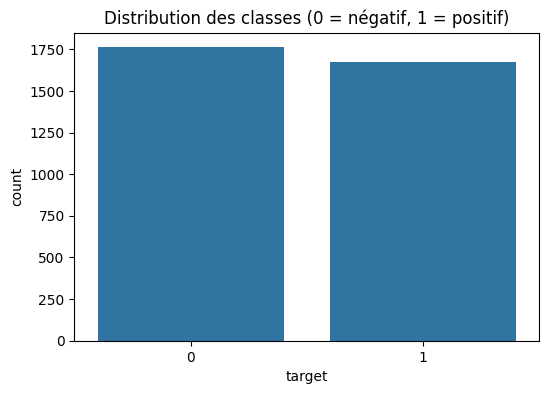

target
0    51.310425
1    48.689575
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='target')
plt.title("Distribution des classes (0 = négatif, 1 = positif)")
plt.show()

print(df['target'].value_counts(normalize=True) * 100)


# **Longueur des commentaires**

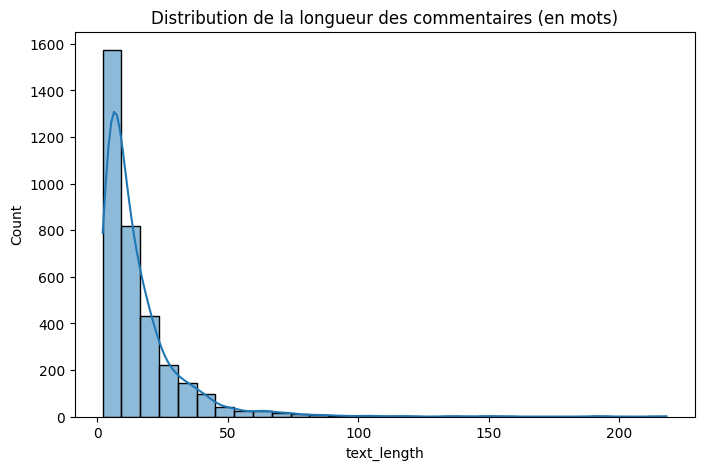

,text_length
count,3434.000000
mean,15.301398
std,15.923216
min,2.000000
25%,6.000000
50%,10.000000
75%,19.000000
max,218.000000


In [ ]:
df["text_length"] = df["comments"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(df["text_length"], bins=30, kde=True)
plt.title("Distribution de la longueur des commentaires (en mots)")
plt.show()

df["text_length"].describe()


# **Exemples de commentaires selon classe**

In [ ]:
print("Exemples classe 0 (négatif):")
print(df[df.target == 0].comments.sample(5, random_state=42))

print("\nExemples classe 1 (positif):")
print(df[df.target == 1].comments.sample(5, random_state=42))


Exemples classe 0 (négatif):
2162    ادعوا النيابة العمومية استدعاء هاته التي تدعي ...
564                                         هذا اكبر عميل
1062    بعدما قبل الرئبس التونسي اكتاف ماكرون علمت انه...
1535    من انت حتى تتوجه للتونسيين يا افشل انسان على و...
3380    القوماني هوا في القوفيد والشعب  قاعد يموت و يط...
Name: comments, dtype: object

Exemples classe 1 (positif):
685                                    كل الدعم لقيس سعيد
930                  مبارك لك يافخامة الرئيس البطل الشجاع
926     لا انتخابات موشوهة ولا تزوير الشعب التونسي قال...
853     الرئيس قيس سعيد يحاول النهوض بماتحطم من الحكوم...
3298    خرجت والعائلة في عز القوائل.. وطنيتنا املت ذلك...
Name: comments, dtype: object


In [ ]:
import pandas as pd

# Créer un DataFrame combiné
examples_df = pd.DataFrame({
    'Exemple': range(1, 6),
    'Classe 0 (Négatif)': df[df.target == 0].comments.sample(5, random_state=42).values,
    'Classe 1 (Positif)': df[df.target == 1].comments.sample(5, random_state=42).values
})

# Afficher avec une largeur de colonne ajustée
pd.set_option('display.max_colwidth', 100)
examples_df

,Exemple,Classe 0 (Négatif),Classe 1 (Positif)
0,1,ادعوا النيابة العمومية استدعاء هاته التي تدعي الصحافة لما تروج له من فتنة وتزوير للانتخابات . ...,كل الدعم لقيس سعيد
1,2,هذا اكبر عميل,مبارك لك يافخامة الرئيس البطل الشجاع
2,3,بعدما قبل الرئبس التونسي اكتاف ماكرون علمت انه مجرد انسان سفيه حقير,لا انتخابات موشوهة ولا تزوير الشعب التونسي قال كلمتوا و أختار قيس سعيد
3,4,من انت حتى تتوجه للتونسيين يا افشل انسان على وجه البسيطة,الرئيس قيس سعيد يحاول النهوض بماتحطم من الحكومات السابقة والفاسدة كيف ها السيد هذا
4,5,القوماني هوا في القوفيد والشعب قاعد يموت و يطالب بالتعويض عليه أن يغادر الساحة السياسية ولا يتك...,خرجت والعائلة في عز القوائل.. وطنيتنا املت ذلك علينا.. فما رأيك يا هذا


# **WordCloud (nuage de mots)**

Nombre de commentaires : 3434
Texte après suppression des stop words tunisiens : 260657 caractères

10 mots les plus fréquents (après nettoyage) :
  'قيس': 1302 fois
  'سعيد': 1191 fois
  'تونس': 876 fois
  'الشعب': 542 fois
  'الله': 368 fois
  'التونسي': 249 fois
  'هذا': 239 fois
  'الرئيس': 217 fois
  'ولا': 178 fois
  'رئيس': 164 fois
✓ Police trouvée : Noto Sans Arabic


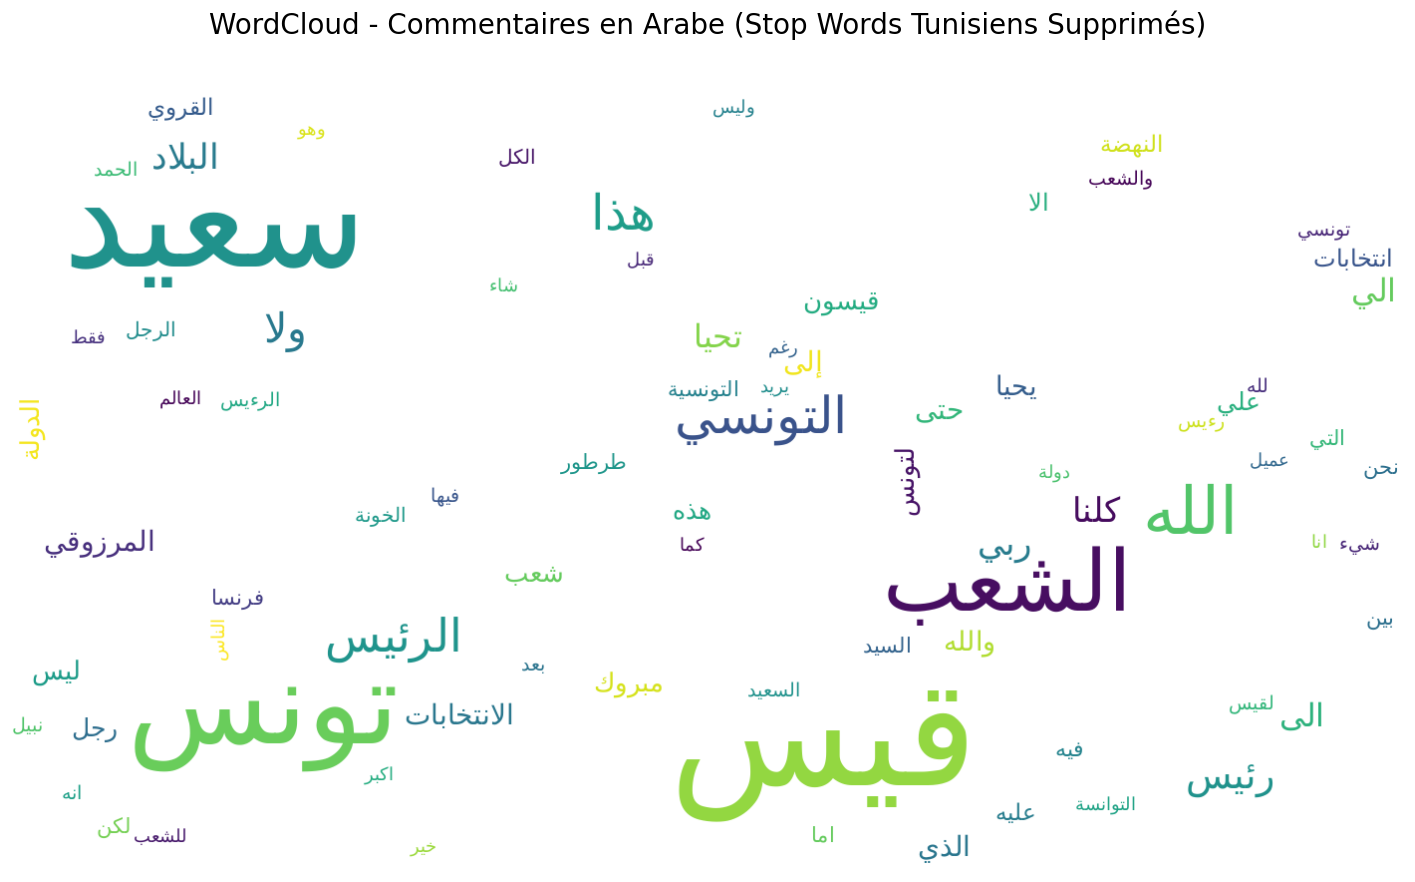


=== EXEMPLES AVANT/APRÈS SUPPRESSION DES STOP WORDS ===

Exemple 1:
Original: لا للانتخابات مع العصابات يا البلاد صحافة العار
Nettoyé: لا للانتخابات مع العصابات يا البلاد صحافة العار
Sans stop words: للانتخابات العصابات البلاد صحافة العار
--------------------------------------------------

Exemple 2:
Original: قيس السعيد ذكرني بالراحل محمد بوضياف رحمه الله. بالتوفيق لشعب التونسي في اختيارهم
Nettoyé: قيس السعيد ذكرني بالراحل محمد بوضياف رحمه الله. بالتوفيق لشعب التونسي في اختيارهم
Sans stop words: قيس السعيد ذكرني بالراحل محمد بوضياف رحمه الله. بالتوفيق لشعب التونسي اختيارهم
--------------------------------------------------

Exemple 3:
Original: في رئيي نبيل القروي مخادع لن يصلح أبدا جزائري محب لتونس الشقيقة
Nettoyé: في رئيي نبيل القروي مخادع لن يصلح أبدا جزائري محب لتونس الشقيقة
Sans stop words: رئيي نبيل القروي مخادع يصلح أبدا جزائري محب لتونس الشقيقة
--------------------------------------------------


In [ ]:
# Installer une police arabe
!apt-get install -y fonts-noto > /dev/null
!fc-cache -fv > /dev/null

import matplotlib.pyplot as plt
from wordcloud import WordCloud
import matplotlib.font_manager as fm
import re

# Liste des stop words tunisiens (arabe dialectal tunisien)
tunisian_stopwords = {
    'و', 'في', 'من', 'على', 'لي', 'اللي', 'يا', 'هو', 'هي', 'هم', 'نحنا', 'انتم',
    'انت', 'انتي', 'كان', 'يكون', 'كيف', 'شنوة', 'ش', 'فمّا', 'فمّة', 'باش', 'باهي',
    'برشا', 'عند', 'عندو', 'عنده', 'عندي', 'عندنا', 'عندكم', 'عندك', 'عندك', 'علاش',
    'لاش', 'مثلا', 'ماعادش', 'مازال', 'مابقاش', 'مات', 'مثلا', 'مثل', 'مش', 'موش',
    'ميكونش', 'نحّو', 'نحو', 'هاذ', 'هاذي', 'هاذو', 'هنا', 'هناك', 'واش', 'وينا',
    'ياك', 'ياها', 'ياهم', 'يه', 'ياه', 'زيد', 'زادة', 'غير', 'قلة', 'قلب', 'كان',
    'كيف', 'كل', 'كله', 'لازمة', 'لازم', 'لحق', 'لما', 'لو', 'لي', 'لول', 'مابقاش',
    'مات', 'مثلا', 'مثل', 'مش', 'مكاش', 'من', 'منين', 'نحنا', 'نحّو', 'نحو', 'نفس',
    'هاذ', 'هاذي', 'هاذو', 'هنا', 'هناك', 'و', 'واش', 'واحد', 'والا', 'والو', 'وين',
    'يا', 'ياك', 'ياها', 'ياهم', 'يه', 'ياه', 'زيد', 'زادة', 'غير', 'قلة', 'قلب',
    'باش', 'باهي', 'برشا', 'علاش', 'لاش', 'مثلا', 'ماعادش', 'مازال', 'مابقاش'
}

def clean_arabic_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\u0600-\u06FF\s\.\!\?،؛]", "", text)
    return text.strip()

def remove_tunisian_stopwords(text):
    """Supprimer les stop words tunisiens"""
    if not isinstance(text, str):
        return ""

    words = text.split()
    filtered_words = [word for word in words if word not in tunisian_stopwords and len(word) > 2]
    return " ".join(filtered_words)

# Appliquer le nettoyage
df["clean"] = df["comments"].apply(clean_arabic_text)

# Supprimer les stop words tunisiens
df["clean_no_stopwords"] = df["clean"].apply(remove_tunisian_stopwords)

# Préparer le texte SANS les stop words
text_all = " ".join(df["clean_no_stopwords"].dropna())

print(f"Nombre de commentaires : {len(df)}")
print(f"Texte après suppression des stop words tunisiens : {len(text_all)} caractères")

# Analyser les mots les plus fréquents
from collections import Counter
words = text_all.split()
word_freq = Counter(words)
print(f"\n10 mots les plus fréquents (après nettoyage) :")
for word, count in word_freq.most_common(10):
    print(f"  '{word}': {count} fois")

# Trouver une police arabe
available_fonts = [f.name for f in fm.fontManager.ttflist]
arabic_fonts = ['Noto Sans Arabic', 'DejaVu Sans', 'Liberation Sans']

font_path = None
for font in arabic_fonts:
    try:
        font_path = fm.findfont(fm.FontProperties(family=font))
        print(f"✓ Police trouvée : {font}")
        break
    except:
        continue

if font_path is None:
    print("ℹ️ Utilisation de la police par défaut")
    font_path = None

# Générer le WordCloud
wordcloud = WordCloud(
    width=1400,
    height=800,
    background_color='white',
    max_words=80,
    collocations=False,
    font_path=font_path,
    min_font_size=15,
    max_font_size=150,
    margin=5,
    relative_scaling=0.7
).generate(text_all)

plt.figure(figsize=(18, 12))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud - Commentaires en Arabe (Stop Words Tunisiens Supprimés)", fontsize=20, pad=30)
plt.show()

# Afficher quelques exemples avant/après
print("\n=== EXEMPLES AVANT/APRÈS SUPPRESSION DES STOP WORDS ===")
sample_data = df[['comments', 'clean', 'clean_no_stopwords']].head(3)
for idx, row in sample_data.iterrows():
    print(f"\nExemple {idx+1}:")
    print(f"Original: {row['comments']}")
    print(f"Nettoyé: {row['clean']}")
    print(f"Sans stop words: {row['clean_no_stopwords']}")
    print("-" * 50)

# **WordCloud par classe**

Texte positif (sans stop words): 124605 caractères
Texte négatif (sans stop words): 136051 caractères

Mots les plus fréquents - Positif:
  'قيس': 993
  'سعيد': 906
  'تونس': 557
  'الشعب': 290
  'الله': 231
  'الرئيس': 165
  'التونسي': 154
  'كلنا': 135

Mots les plus fréquents - Négatif:
  'تونس': 319
  'قيس': 309
  'سعيد': 285
  'الشعب': 252
  'هذا': 157
  'الله': 137
  'ولا': 96
  'التونسي': 95

✓ Police trouvée : Noto Sans Arabic


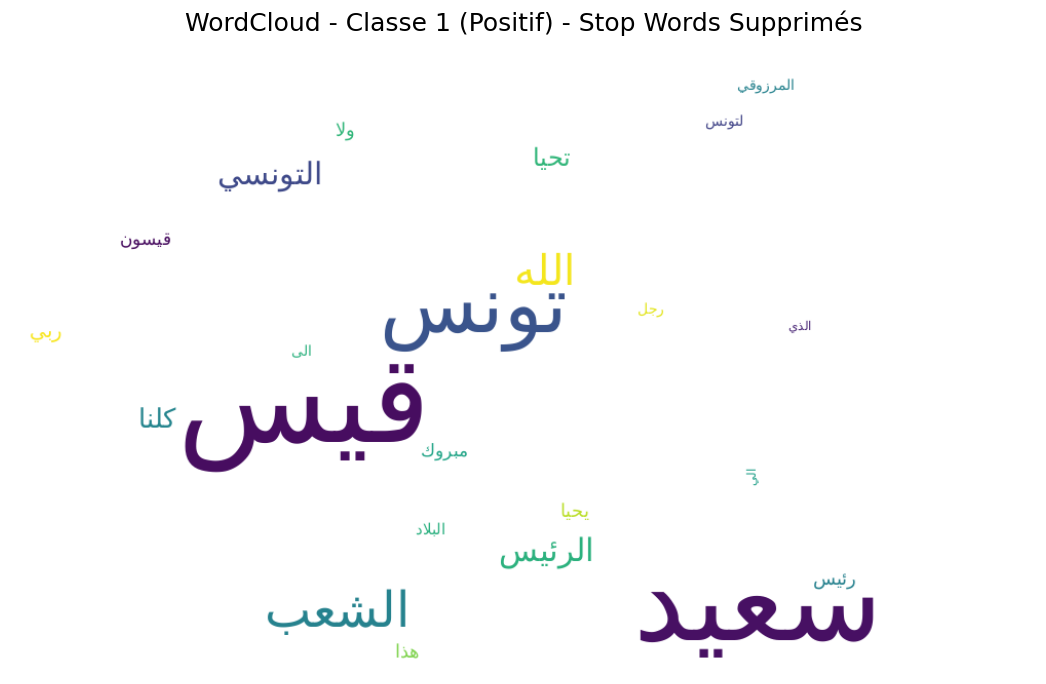

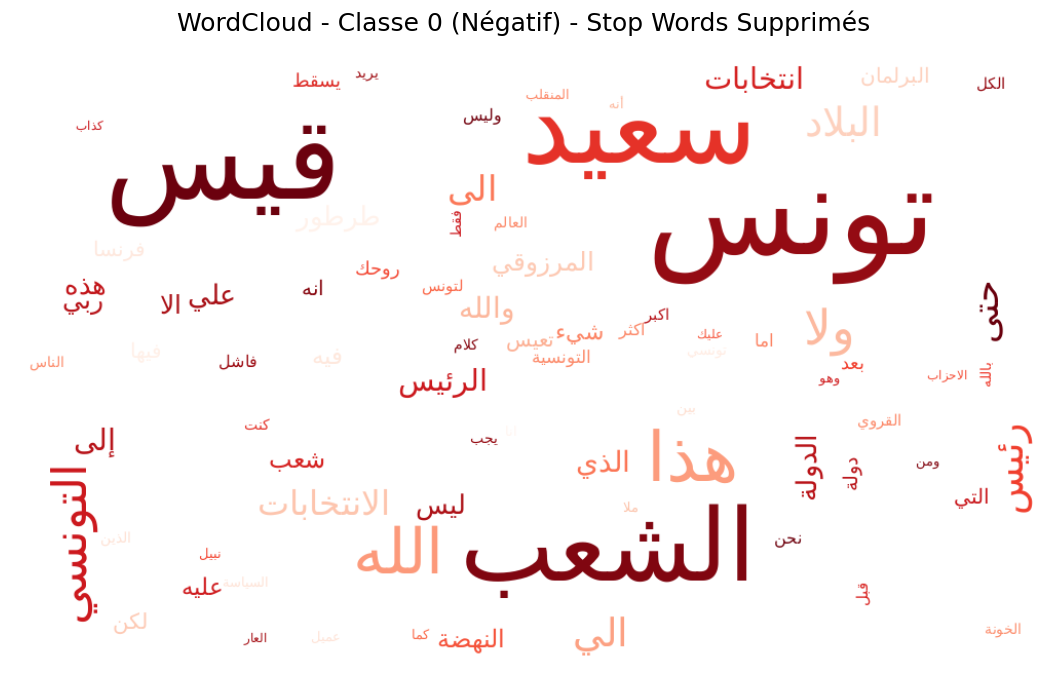


EXEMPLES AVANT/APRÈS SUPPRESSION DES STOP WORDS

Exemple 1:
Original: لا للانتخابات مع العصابات يا البلاد صحافة العار
Sans stop words: للانتخابات العصابات البلاد صحافة العار
--------------------------------------------------

Exemple 2:
Original: قيس السعيد ذكرني بالراحل محمد بوضياف رحمه الله. بالتوفيق لشعب التونسي في اختيارهم
Sans stop words: قيس السعيد ذكرني بالراحل محمد بوضياف رحمه الله. بالتوفيق لشعب التونسي اختيارهم
--------------------------------------------------


In [ ]:
# Installer une police arabe
!apt-get install -y fonts-noto > /dev/null
!fc-cache -fv > /dev/null

import matplotlib.pyplot as plt
from wordcloud import WordCloud
import matplotlib.font_manager as fm
import re

# Liste des stop words tunisiens (arabe dialectal tunisien)
tunisian_stopwords = {
    'و', 'في', 'من', 'على', 'لي', 'اللي', 'يا', 'هو', 'هي', 'هم', 'نحنا', 'انتم',
    'انت', 'انتي', 'كان', 'يكون', 'كيف', 'شنوة', 'ش', 'فمّا', 'فمّة', 'باش', 'باهي',
    'برشا', 'عند', 'عندو', 'عنده', 'عندي', 'عندنا', 'عندكم', 'عندك', 'عندك', 'علاش',
    'لاش', 'مثلا', 'ماعادش', 'مازال', 'مابقاش', 'مات', 'مثلا', 'مثل', 'مش', 'موش',
    'ميكونش', 'نحّو', 'نحو', 'هاذ', 'هاذي', 'هاذو', 'هنا', 'هناك', 'واش', 'وينا',
    'ياك', 'ياها', 'ياهم', 'يه', 'ياه', 'زيد', 'زادة', 'غير', 'قلة', 'قلب', 'كان',
    'كيف', 'كل', 'كله', 'لازمة', 'لازم', 'لحق', 'لما', 'لو', 'لي', 'لول', 'مابقاش',
    'مات', 'مثلا', 'مثل', 'مش', 'mكاش', 'من', 'منين', 'نحنا', 'نحّو', 'نحو', 'نفس',
    'هاذ', 'هاذي', 'هاذو', 'هنا', 'هناك', 'و', 'واش', 'واحد', 'والا', 'والو', 'وين',
    'يا', 'ياك', 'ياها', 'ياهم', 'يه', 'ياه', 'زيد', 'زادة', 'غير', 'قلة', 'قلب',
    'باش', 'باهي', 'برشا', 'علاش', 'لاش', 'مثلا', 'ماعادش', 'مازال', 'مابقاش'
}

def clean_arabic_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\u0600-\u06FF\s\.\!\?،؛]", "", text)
    return text.strip()

def remove_tunisian_stopwords(text):
    """Supprimer les stop words tunisiens"""
    if not isinstance(text, str):
        return ""

    words = text.split()
    filtered_words = [word for word in words if word not in tunisian_stopwords and len(word) > 2]
    return " ".join(filtered_words)

# Appliquer le nettoyage et suppression des stop words
df["clean_no_stopwords"] = df["comments"].apply(clean_arabic_text).apply(remove_tunisian_stopwords)

# Préparer les textes SANS stop words
text_pos = " ".join(df[df.target == 1]["clean_no_stopwords"])
text_neg = " ".join(df[df.target == 0]["clean_no_stopwords"])

print(f"Texte positif (sans stop words): {len(text_pos)} caractères")
print(f"Texte négatif (sans stop words): {len(text_neg)} caractères")

# Afficher quelques mots fréquents pour vérification
from collections import Counter

print("\nMots les plus fréquents - Positif:")
pos_words = Counter(text_pos.split())
for word, count in pos_words.most_common(8):
    print(f"  '{word}': {count}")

print("\nMots les plus fréquents - Négatif:")
neg_words = Counter(text_neg.split())
for word, count in neg_words.most_common(8):
    print(f"  '{word}': {count}")

# Trouver une police arabe
available_fonts = [f.name for f in fm.fontManager.ttflist]
arabic_fonts = ['Noto Sans Arabic', 'DejaVu Sans', 'Liberation Sans']

font_path = None
for font in arabic_fonts:
    try:
        font_path = fm.findfont(fm.FontProperties(family=font))
        print(f"\n✓ Police trouvée : {font}")
        break
    except:
        continue

if font_path is None:
    print("ℹ️ Utilisation de la police par défaut")
    font_path = None

# WordCloud pour la classe positive
wc_pos = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    max_words=80,
    collocations=False,
    font_path=font_path,
    min_font_size=12,
    max_font_size=120,
    relative_scaling=0.8,
    colormap='viridis'  # Couleurs positives
).generate(text_pos)

plt.figure(figsize=(16, 8))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud - Classe 1 (Positif) - Stop Words Supprimés", fontsize=18, pad=20)
plt.show()

# WordCloud pour la classe négative
wc_neg = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    max_words=80,
    collocations=False,
    font_path=font_path,
    min_font_size=12,
    max_font_size=120,
    relative_scaling=0.8,
    colormap='Reds'  # Couleurs négatives
).generate(text_neg)

plt.figure(figsize=(16, 8))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud - Classe 0 (Négatif) - Stop Words Supprimés", fontsize=18, pad=20)
plt.show()

# Afficher des exemples avant/après
print("\n" + "="*60)
print("EXEMPLES AVANT/APRÈS SUPPRESSION DES STOP WORDS")
print("="*60)

sample_data = df[['comments', 'clean_no_stopwords']].head(2)
for idx, row in sample_data.iterrows():
    print(f"\nExemple {idx+1}:")
    print(f"Original: {row['comments']}")
    print(f"Sans stop words: {row['clean_no_stopwords']}")
    print("-" * 50)

# **Top N-grams (unigram, bigram, trigram)**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [ ]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)              # remove URLs
    text = re.sub(r"[^؀-ۿa-zA-Z0-9\s]", " ", text)  # Arabic + Latin + numbers
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean"] = df["comments"].apply(clean_text)


In [ ]:
def get_top_ngrams(texts, n=1, k=20, remove_stopwords=True):
    # Liste des stop words tunisiens
    tunisian_stopwords = {
        'و', 'في', 'من', 'على', 'لي', 'اللي', 'يا', 'هو', 'هي', 'هم', 'نحنا', 'انتم',
        'انت', 'انتي', 'كان', 'يكون', 'كيف', 'شنوة', 'ش', 'فمّا', 'فمّة', 'باش', 'باهي',
        'برشا', 'عند', 'عندو', 'عنده', 'عندي', 'عندنا', 'عندكم', 'عندك', 'عندك', 'علاش',
        'لاش', 'مثلا', 'ماعادش', 'مازال', 'مابقاش', 'مات', 'مثلا', 'مثل', 'مش', 'موش',
        'ميكونش', 'نحّو', 'نحو', 'هاذ', 'hهاذي', 'هاذو', 'هنا', 'هناك', 'واش', 'وينا',
        'ياك', 'ياها', 'ياهم', 'يه', 'ياه', 'زيد', 'زادة', 'غير', 'قلة', 'قلب', 'كان',
        'كيف', 'كل', 'كله', 'لازمة', 'لازم', 'لحق', 'لما', 'لو', 'لي', 'لول', 'مابقاش',
        'مات', 'مثلا', 'مثل', 'مش', 'مكاش', 'من', 'منين', 'نحنا', 'نحّو', 'نحو', 'نفس',
        'هاذ', 'هاذي', 'هاذو', 'هنا', 'هناك', 'و', 'واش', 'واحد', 'والا', 'والو', 'وين',
        'يا', 'ياك', 'ياها', 'ياهم', 'يه', 'ياه', 'زيد', 'زادة', 'غير', 'قلة', 'قلب',
        'باش', 'باهي', 'برشا', 'علاش', 'لاش', 'مثلا', 'ماعادش', 'مازال', 'مابقاش'
    }

    # Paramètres du vectorizer
    vectorizer_params = {
        'ngram_range': (n, n),
        'min_df': 2,
        'max_features': 10000
    }

    # Ajouter le paramètre stop_words si demandé
    if remove_stopwords:
        vectorizer_params['stop_words'] = list(tunisian_stopwords)

    vectorizer = CountVectorizer(**vectorizer_params)
    X = vectorizer.fit_transform(texts)
    sums = X.sum(axis=0)

    freqs = [(word, sums[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    freqs = sorted(freqs, key=lambda x: x[1], reverse=True)
    return freqs[:k]

In [ ]:
# Exemples d'utilisation

# 1. Unigrammes sans stop words (par défaut)
top_unigrams = get_top_ngrams(df['clean'], n=1, k=15)
print("Top 15 unigrammes (sans stop words):")
for word, freq in top_unigrams:
    print(f"  {word}: {freq}")

# 2. Bigrammes sans stop words
top_bigrams = get_top_ngrams(df['clean'], n=2, k=15)
print("\nTop 15 bigrammes (sans stop words):")
for word, freq in top_bigrams:
    print(f"  {word}: {freq}")

# 3. Trigrammes sans stop words
top_trigrams = get_top_ngrams(df['clean'], n=3, k=10)
print("\nTop 10 trigrammes (sans stop words):")
for word, freq in top_trigrams:
    print(f"  {word}: {freq}")

# 4. Avec stop words (pour comparaison)
top_with_stopwords = get_top_ngrams(df['clean'], n=1, k=10, remove_stopwords=False)
print("\nTop 10 unigrammes (avec stop words):")
for word, freq in top_with_stopwords:
    print(f"  {word}: {freq}")

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['فم', 'نح'] not in stop_words.
  warnings.warn(


Top 15 unigrammes (sans stop words):
  قيس: 1326
  سعيد: 1230
  تونس: 913
  لا: 580
  الشعب: 563
  الله: 384
  ما: 273
  التونسي: 261
  هذا: 246
  الرئيس: 221
  مع: 201
  ان: 193
  ولا: 185
  رئيس: 166
  لم: 150

Top 15 bigrammes (sans stop words):
  قيس سعيد: 1038
  الشعب التونسي: 168
  تحيا تونس: 108
  كلنا قيس: 100
  الرئيس قيس: 77
  يحيا قيس: 55
  مع قيس: 49
  شاء الله: 43
  لقيس سعيد: 38
  قيس السعيد: 34
  سعيد رئيس: 34
  الحمد لله: 31
  سعيد لا: 30
  نبيل القروي: 27
  بن علي: 26

Top 10 trigrammes (sans stop words):
  كلنا قيس سعيد: 86
  الرئيس قيس سعيد: 71
  يحيا قيس سعيد: 48
  مع قيس سعيد: 36
  قيس سعيد رئيس: 30
  ان شاء الله: 25
  قيس سعيد لا: 25
  تحيا تونس تحيا: 21
  تونس تحيا تونس: 21
  قيس سعيد ولا: 20

Top 10 unigrammes (avec stop words):
  قيس: 1326
  سعيد: 1230
  في: 1071
  من: 1004
  تونس: 913
  لا: 580
  الشعب: 563
  على: 547
  يا: 536
  الله: 384


# **Partie Entrainement:**

# **1-Tunbert**:

In [ ]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix ,classification_report
import pandas as pd

In [ ]:
# 1. Charger et split dataset
df = pd.read_excel("/content/final_result1.xlsx")
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['target'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['target'])


In [ ]:
print(f"\nTrain: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")


Train: 2403, Validation: 515, Test: 516


In [ ]:
train_dataset = Dataset.from_pandas(train_df[['comments', 'target']])
val_dataset = Dataset.from_pandas(val_df[['comments', 'target']])
test_dataset = Dataset.from_pandas(test_df[['comments', 'target']])

In [ ]:
model_name = "tunis-ai/TunBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    trust_remote_code=True,
    num_labels=2
)


In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples['comments'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

In [ ]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/2403 [00:00<?, ? examples/s]

Map:   0%|          | 0/515 [00:00<?, ? examples/s]

Map:   0%|          | 0/516 [00:00<?, ? examples/s]

In [ ]:
train_dataset = train_dataset.rename_column("target", "labels")
val_dataset = val_dataset.rename_column("target", "labels")
test_dataset = test_dataset.rename_column("target", "labels")

In [ ]:
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
val_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    # Gérer le cas où predictions est un tuple
    predictions = pred.predictions[0] if isinstance(pred.predictions, tuple) else pred.predictions
    preds = predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary'
    )
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./tunbert_finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs",
    logging_steps=50,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),  # Utiliser mixed precision si GPU disponible
    report_to="none",  # Désactiver les rapports automatiques
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

In [ ]:
print("\n🚀 Début de l'entraînement...")
trainer.train()


🚀 Début de l'entraînement...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.323500,0.479822,0.838835,0.829569,0.855932,0.804781
2,0.322700,0.454842,0.840777,0.838583,0.828794,0.848606
3,0.271800,0.640067,0.846602,0.848369,0.818519,0.880478


TrainOutput(global_step=903, training_loss=0.29736973304025094, metrics={'train_runtime': 150.1915, 'train_samples_per_second': 47.999, 'train_steps_per_second': 6.012, 'total_flos': 477461719217664.0, 'train_loss': 0.29736973304025094, 'epoch': 3.0})

In [ ]:
print("\n📊 Évaluation sur l'ensemble de test...")
test_results = trainer.evaluate(test_dataset)
print(f"Résultats sur test: {test_results}")


📊 Évaluation sur l'ensemble de test...


Résultats sur test: {'eval_loss': 0.7415593862533569, 'eval_accuracy': 0.8158914728682171, 'eval_f1': 0.8111332007952287, 'eval_precision': 0.8095238095238095, 'eval_recall': 0.8127490039840638, 'eval_runtime': 2.1115, 'eval_samples_per_second': 244.381, 'eval_steps_per_second': 15.629, 'epoch': 3.0}


In [ ]:
# 14. Prédictions sur l'ensemble de test
predictions = trainer.predict(test_dataset)
# Gérer le cas où predictions est un tuple
pred_logits = predictions.predictions[0] if isinstance(predictions.predictions, tuple) else predictions.predictions
preds = pred_logits.argmax(-1)
labels = predictions.label_ids

In [ ]:
cm = confusion_matrix(labels, preds)
print(f"\nMatrice de confusion:\n{cm}")


Matrice de confusion:
[[217  48]
 [ 47 204]]


In [ ]:
print("\n📋 Rapport de classification:")
print("="*60)
report = classification_report(labels, preds, target_names=['Classe 0', 'Classe 1'], digits=4)
print(report)

# Calcul des métriques supplémentaires
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"\n📈 Métriques supplémentaires:")
print(f"Sensibilité (Recall Classe 1): {sensitivity:.4f}")
print(f"Spécificité (Recall Classe 0): {specificity:.4f}")
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")


📋 Rapport de classification:
              precision    recall  f1-score   support

    Classe 0     0.8220    0.8189    0.8204       265
    Classe 1     0.8095    0.8127    0.8111       251

    accuracy                         0.8159       516
   macro avg     0.8157    0.8158    0.8158       516
weighted avg     0.8159    0.8159    0.8159       516


📈 Métriques supplémentaires:
Sensibilité (Recall Classe 1): 0.8127
Spécificité (Recall Classe 0): 0.8189
True Positives: 204
True Negatives: 217
False Positives: 48
False Negatives: 47


In [ ]:
import shutil

# Sauvegarde du modèle et du tokenizer
model.save_pretrained("./tunbert_final_model")
tokenizer.save_pretrained("./tunbert_final_model")
print("\n✅ Modèle sauvegardé dans ./tunbert_final_model")

# Création d'un fichier zip pour téléchargement
shutil.make_archive("tunbert_final_model", 'zip', "./tunbert_final_model")
print("✅ Modèle compressé dans tunbert_final_model.zip")



✅ Modèle sauvegardé dans ./tunbert_final_model
✅ Modèle compressé dans tunbert_final_model.zip
